In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [2]:
# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md
import kagglehub
kagglehub.dataset_download('avnishnish/mnist-original')

'/kaggle/input/datasets/avnishnish/mnist-original'

In [4]:
mnist = loadmat("/kaggle/input/datasets/avnishnish/mnist-original/mnist-original.mat")
mnist_data = mnist["data"].T
mnist_label = mnist["label"][0]
print(mnist_data.shape)
print(mnist_label.shape)

(70000, 784)
(70000,)


In [5]:
mnist_2d = mnist_data.reshape(-1, 28, 28)

In [6]:
mnist_2d[10]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         28, 195, 254, 254, 254, 254, 254, 255,  61,   0,   0,   0,   0,
          0,   0],
       [  

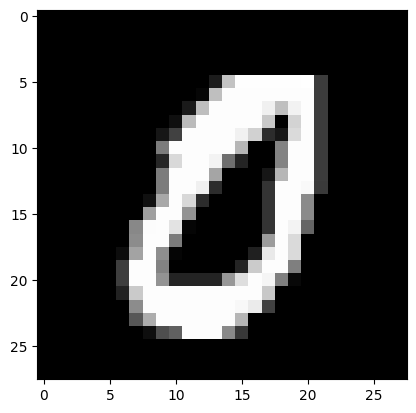

In [5]:
plt.imshow(mnist_2d[10], cmap='gray')

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [7]:
# The model is simple to save space in the ESP32-S3
class MNISTEsp32Net(nn.Module):
    def __init__(self):
        super(MNISTEsp32Net, self).__init__()
        # Using relu since it maps negative values cleanly to 0.
        self.network = nn.Sequential(
            nn.Linear(784, 100),
            nn.ReLU(),
            nn.Linear(100, 40),
            nn.ReLU(),
            nn.Linear(40, 10)
        )
        
    def forward(self, x):
        return self.network(x)

# data setup
X_raw = (mnist_data - np.min(mnist_data)) / (np.max(mnist_data) - np.min(mnist_data)).astype(np.float32)
y_raw = mnist_label.astype(np.int64)

# Train-Test Split: 60k train, 10k test
X_train, X_test = torch.tensor(X_raw[:60000]), torch.tensor(X_raw[60000:])
y_train, y_test = torch.tensor(y_raw[:60000]), torch.tensor(y_raw[60000:])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNISTEsp32Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training model...")
model.train()
for epoch in range(30):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Training model...
Epoch 1, Loss: 0.3747
Epoch 2, Loss: 0.1668
Epoch 3, Loss: 0.1186
Epoch 4, Loss: 0.0913
Epoch 5, Loss: 0.0718
Epoch 6, Loss: 0.0596
Epoch 7, Loss: 0.0491
Epoch 8, Loss: 0.0392
Epoch 9, Loss: 0.0336
Epoch 10, Loss: 0.0286
Epoch 11, Loss: 0.0241
Epoch 12, Loss: 0.0211
Epoch 13, Loss: 0.0166
Epoch 14, Loss: 0.0173
Epoch 15, Loss: 0.0139
Epoch 16, Loss: 0.0136
Epoch 17, Loss: 0.0124
Epoch 18, Loss: 0.0114
Epoch 19, Loss: 0.0107
Epoch 20, Loss: 0.0102
Epoch 21, Loss: 0.0074
Epoch 22, Loss: 0.0089
Epoch 23, Loss: 0.0088
Epoch 24, Loss: 0.0094
Epoch 25, Loss: 0.0064
Epoch 26, Loss: 0.0064
Epoch 27, Loss: 0.0067
Epoch 28, Loss: 0.0081
Epoch 29, Loss: 0.0067
Epoch 30, Loss: 0.0043


In [8]:
# Symmetrically quantize tensor to int8
def quantize_to_int8(tensor):
    float_weights = tensor.detach().cpu().numpy()
    
    # Take maximum absolute value as scale factor
    max_val = np.max(np.abs(float_weights))
    
    # Prevent division by zero if weights are empty or zero
    if max_val == 0:
        return float_weights.astype(np.int8), 1.0
        
    # Calculate scale factor: maps max_val to 127
    scale = 127.0 / max_val
    
    # Quantize, round, and clip to valid int8 boundaries
    quantized_weights = np.round(float_weights * scale)
    quantized_weights = np.clip(quantized_weights, -128, 127).astype(np.int8)
    
    # The scale stored here is used during inference to dequantize (or rescale) layer outputs
    return quantized_weights, scale

# Extract and quantize
model.eval()
state_dict = model.state_dict()

quantized_model = {}
for key in state_dict.keys():
    if 'weight' in key or 'bias' in key:
        q_weights, scale = quantize_to_int8(state_dict[key])
        quantized_model[key] = {
            "int8_data": q_weights,
            "scale": scale
        }
        print(f"Layer: {key} | Shape: {q_weights.shape} | Quantization Scale: {scale:.4f}")

# first layer's quantized int8 weights
first_layer_weights = quantized_model['network.0.weight']['int8_data']

Layer: network.0.weight | Shape: (100, 784) | Quantization Scale: 105.4091
Layer: network.0.bias | Shape: (100,) | Quantization Scale: 323.9082
Layer: network.2.weight | Shape: (40, 100) | Quantization Scale: 101.2899
Layer: network.2.bias | Shape: (40,) | Quantization Scale: 384.2485
Layer: network.4.weight | Shape: (10, 40) | Quantization Scale: 107.5882
Layer: network.4.bias | Shape: (10,) | Quantization Scale: 567.7819


In [9]:
def export_to_c_header(quantized_model, filename="model_weights.h"):
    with open(filename, "w") as f:
        f.write("#pragma once\n#include <stdint.h>\n\n")
        
        for key, data in quantized_model.items():
            q_weights = data["int8_data"] # quantized weights
            scale = data["scale"]
            
            # since dots are invalid in a variable name
            clean_name = key.replace('.', '_')
            
            # Flatten the N-dimensional numpy array to a 1D C array
            flat_weights = q_weights.flatten()
            array_str = ", ".join(map(str, flat_weights))
            
            f.write(f"// Original Shape: {q_weights.shape}\n")
            f.write(f"const float {clean_name}_scale = {scale}f;\n")
            f.write(f"const int8_t {clean_name}[{len(flat_weights)}] = {{{array_str}}};\n\n")

export_to_c_header(quantized_model)

In [10]:
# import torchvision.datasets as datasets

In [5]:
# mnist_test = datasets.MNIST(root='./data', train=False, download=True)

In [6]:
# image, label = mnist_test[0]

In [11]:
# np.array(image)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  